Exploratory Data Analysis (EDA).


Which transaction types are most associated with fraud?
What transaction amounts are typical for fraudulent activity?
Which receiver accounts appear most suspicious?
What insights should feed the Receiver Risk Engine?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",None)

df = pd.read_csv(r"D:\SecurePay-AI\dataset\cleaned\transactions_clean.csv")

In [4]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.tail()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [6]:
df.shape

(6362620, 11)

In [7]:
# fraud distribution analysis 

# how many transaction are fraudulent ?

df["isfraud"].value_counts()

isfraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
# fraud percentage 

fraud_percentage = (
    df["isfraud"].value_counts(normalize=True)*100
).round(2)

print(fraud_percentage)

isfraud
0    99.87
1     0.13
Name: proportion, dtype: float64


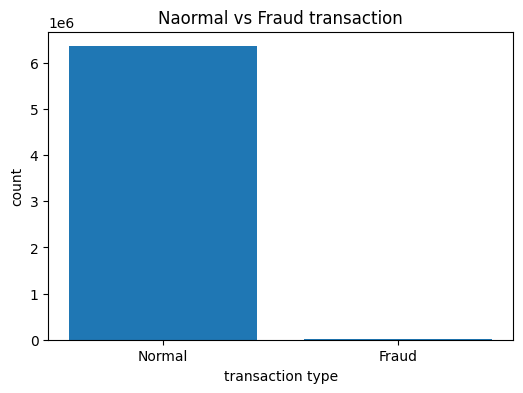

In [9]:
# count plot

fraud_count = df["isfraud"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    ["Normal","Fraud"],
    fraud_count.values
)

plt.title("Naormal vs Fraud transaction")
plt.xlabel("transaction type")
plt.ylabel("count")
plt.show()

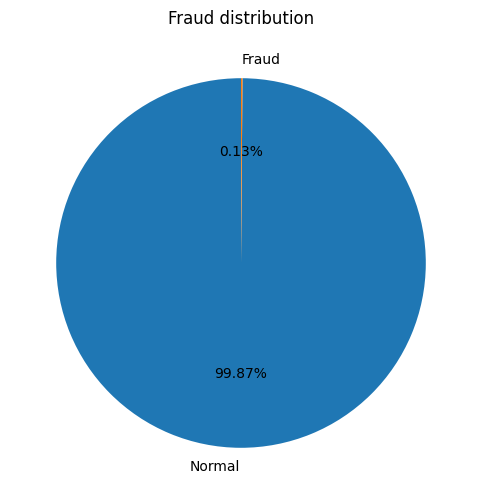

In [10]:
#pie chart 

plt.figure(figsize=(6,6))

plt.pie(
    fraud_count.values,
    labels=["Normal","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Fraud distribution")
plt.show()

In [11]:
# Transaction Type Analysis

# most common transaction type 

df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [12]:
# fraud percentage by transaction type

fraud_table =(
    pd.crosstab(
        df["type"],
        df["isfraud"],
        normalize="index"
    )*100
)

fraud_table

isfraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


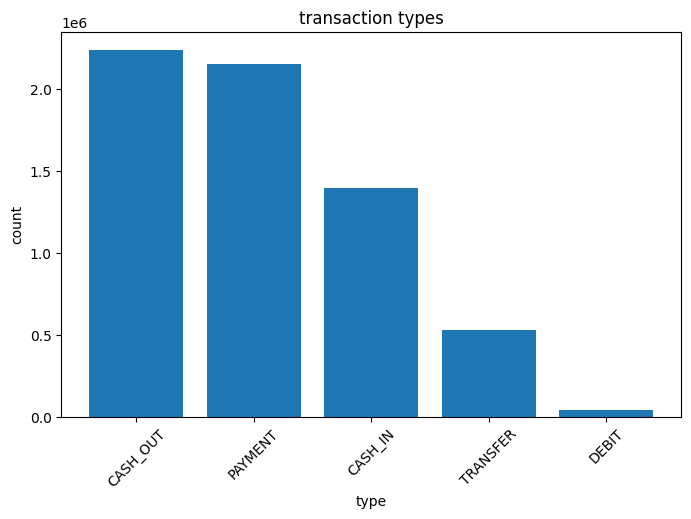

In [13]:
# transaction count 

transaction_counts = df["type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
     transaction_counts.index,
     transaction_counts.values
    )

plt.title("transaction types")
plt.xlabel("type")
plt.ylabel("count")
plt.xticks(rotation = 45)

plt.show()

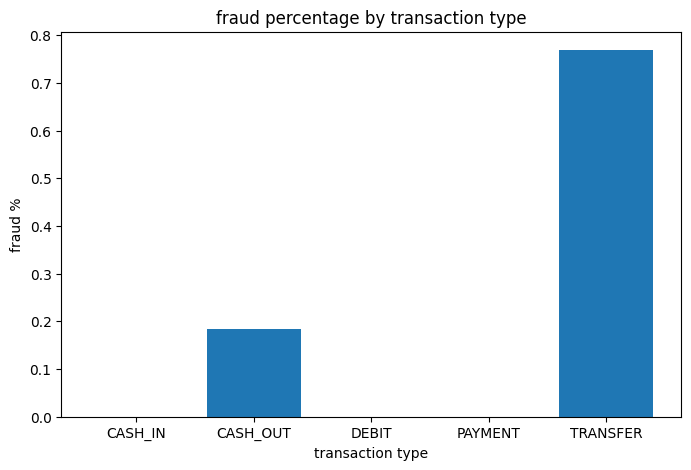

In [14]:
# fraud percentage 

fraud_percent = fraud_table[1]

plt.figure(figsize=(8,5))

plt.bar(
    fraud_percent.index,
    fraud_percent.values
)

plt.title("fraud percentage by transaction type")
plt.xlabel("transaction type")
plt.ylabel("fraud %")

plt.show()

In [15]:
# transaction amount analysis 

print("avg:",df["amount"].mean())
print("median:",df["amount"].median())
print("maximum:",df["amount"].max())
print("minimum:",df["amount"].min())

avg: 179861.90354913071
median: 74871.94
maximum: 92445516.64
minimum: 0.0


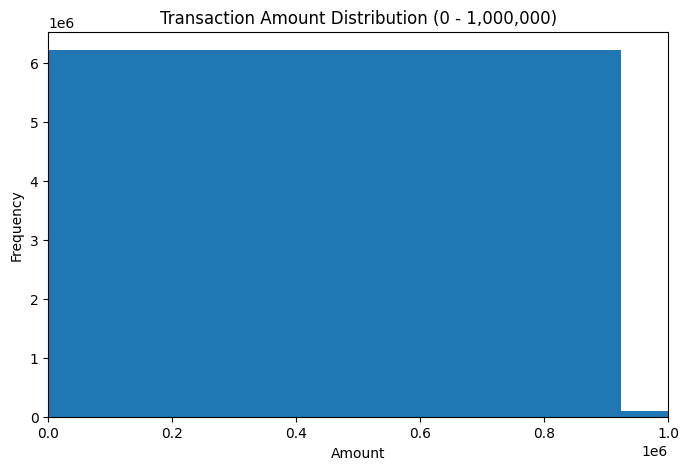

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    df["amount"],
    bins=100
)

plt.xlim(0, 1000000)   # Display transactions up to 1 million

plt.title("Transaction Amount Distribution (0 - 1,000,000)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

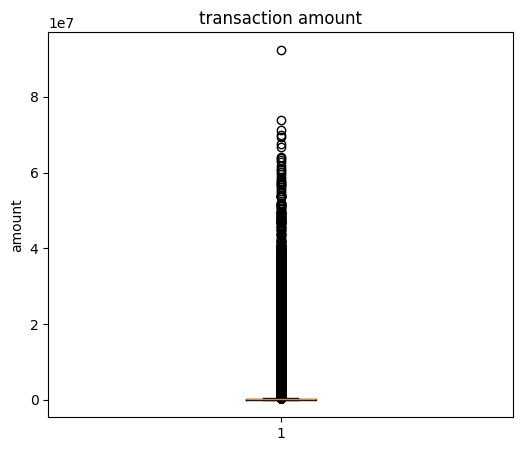

In [17]:
# box plot 

plt.figure(figsize=(6,5))

plt.boxplot(df["amount"])
plt.title("transaction amount")
plt.ylabel("amount")
plt.show()

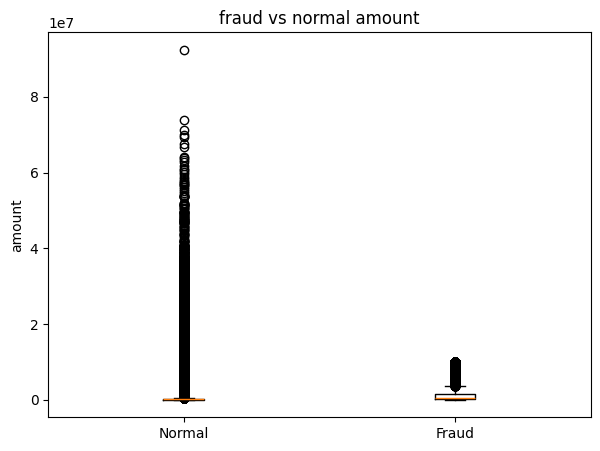

In [18]:
# fraud vs normal amount 

fraud=df[df["isfraud"]==1]["amount"]
normal=df[df["isfraud"]==0]["amount"]

plt.figure(figsize=(7,5))

plt.boxplot(
    [normal,fraud],
    tick_labels=["Normal","Fraud"]
)

plt.title("fraud vs normal amount")

plt.ylabel("amount")

plt.show()

In [19]:
# sender analysis 
#top senders 

top_sender = df["nameorig"].value_counts().head(10)
top_sender

nameorig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

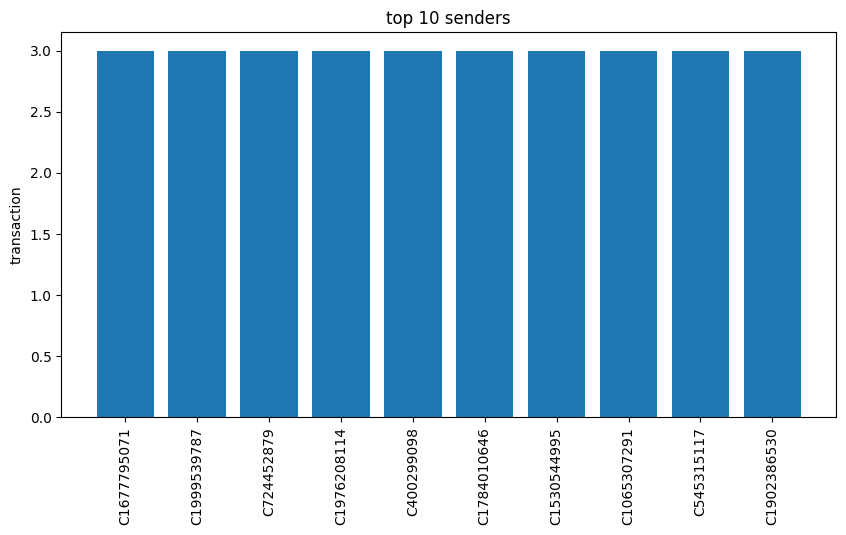

In [20]:
# visualization 

plt.figure(figsize=(10,5))
plt.bar(
    top_sender.index,
    top_sender.values
)
plt.xticks(rotation=90)
plt.title("top 10 senders")
plt.ylabel("transaction")
plt.show()

In [22]:
# top sender amount 
top_sender_amount = (
    df.groupby("nameorig")["amount"].sum().sort_values(ascending=False).head(10)
)
top_sender_amount

nameorig
C1715283297    92445516.64
C2127282686    73823490.36
C2044643633    71172480.42
C1425667947    69886731.30
C1584456031    69337316.27
C811810230     67500761.29
C420748282     66761272.21
C1139847449    64234448.19
C300140823     63847992.58
C372535854     63294839.63
Name: amount, dtype: float64

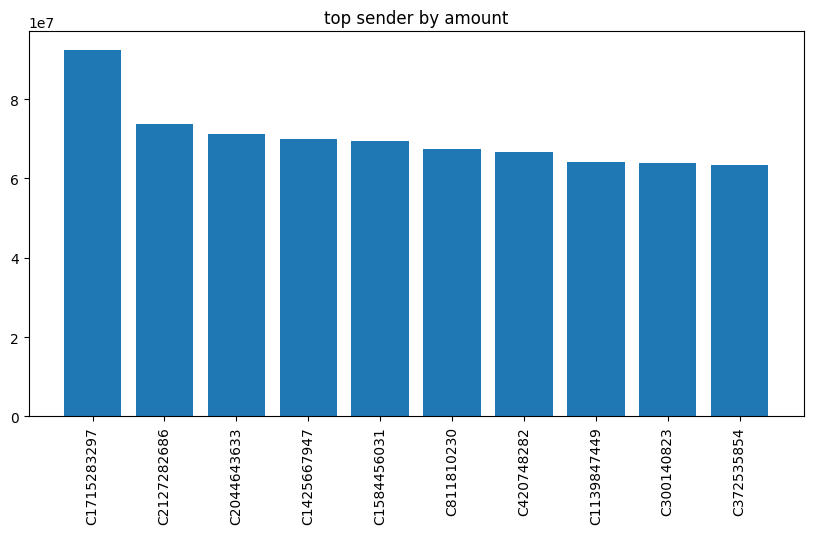

In [23]:
# visualization 

plt.figure(figsize=(10,5))
plt.bar(
    top_sender_amount.index,
    top_sender_amount.values
)
plt.xticks(rotation=90)
plt.title("top sender by amount")
plt.show()

In [26]:
# reciever analysis 

#top reciver
top_receiver = df["namedest"].value_counts().head(10)

top_receiver

namedest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

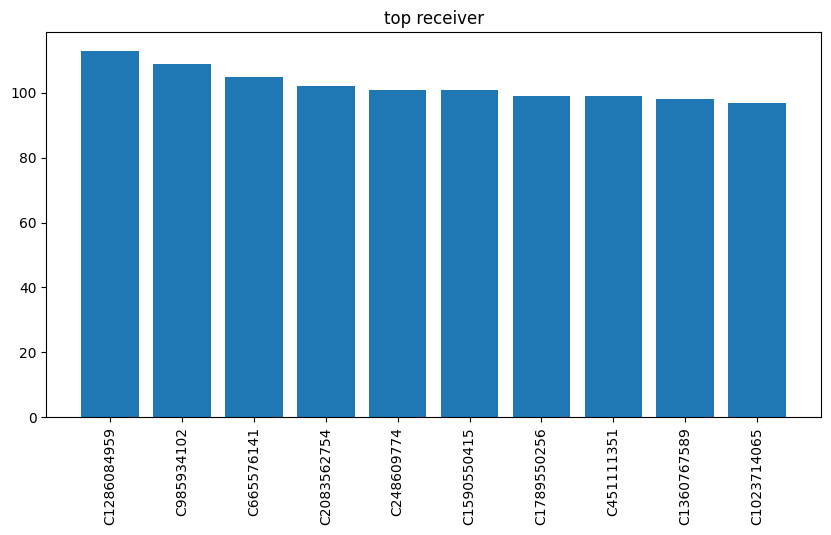

In [27]:
#visualization 

plt.figure(figsize=(10,5))

plt.bar(
    top_receiver.index,
    top_receiver.values
)

plt.xticks(rotation=90)
plt.title("top receiver")
plt.show()

In [28]:
# receiver total amount 

receiver_amount = (
    df.groupby("namedest")["amount"].sum().sort_values(ascending=False).head(10)
)
receiver_amount

namedest
C439737079     3.574408e+08
C707403537     2.993744e+08
C167875008     2.747364e+08
C20253152      2.701162e+08
C172409641     2.553102e+08
C268913927     2.534846e+08
C936857833     2.277800e+08
C65111466      2.274438e+08
C744189981     2.251739e+08
C1406193485    2.247790e+08
Name: amount, dtype: float64

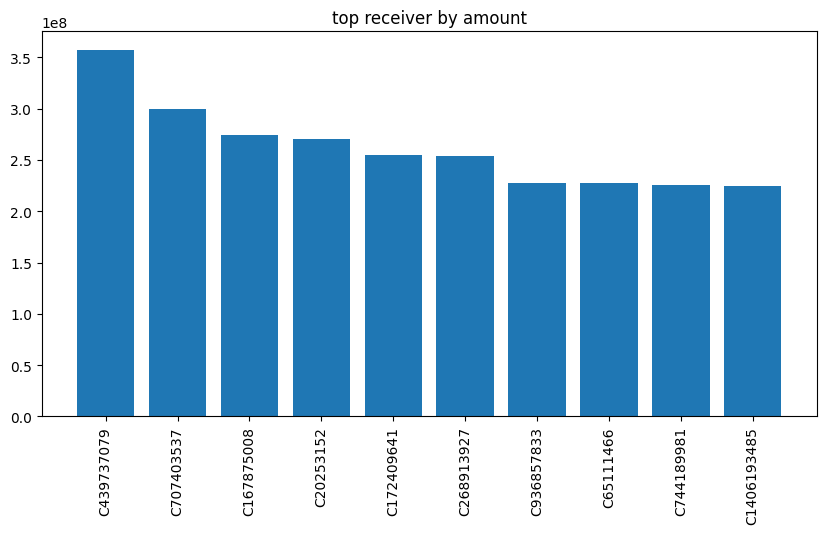

In [30]:
# visualization

plt.figure(figsize=(10,5))
plt.bar(
    receiver_amount.index,
    receiver_amount.values
)
plt.xticks(rotation=90)
plt.title("top receiver by amount")
plt.show()

In [31]:
#receiver fraud count 

receiver_fraud = (
    df[df["isfraud"]==1].groupby("namedest").size().sort_values(ascending=False).head(10)
)
receiver_fraud

namedest
C1399829166    2
C14138104      2
C1656842502    2
C1497532505    2
C1650668671    2
C1325541393    2
C104038589     2
C1780714769    2
C185805228     2
C1185292292    2
dtype: int64

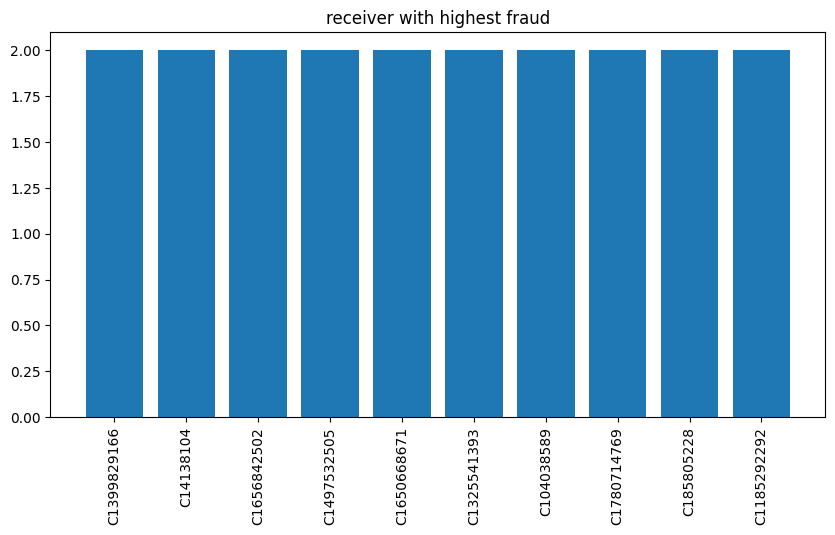

In [33]:
#visualization 
plt.figure(figsize=(10,5))

plt.bar(
    receiver_fraud.index,
    receiver_fraud.values
)

plt.xticks(rotation=90)
plt.title("receiver with highest fraud")
plt.show()

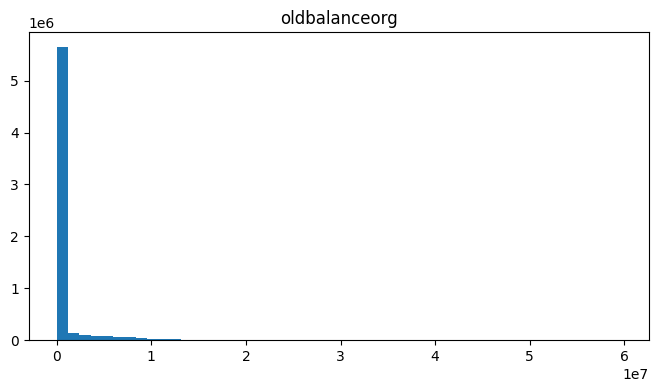

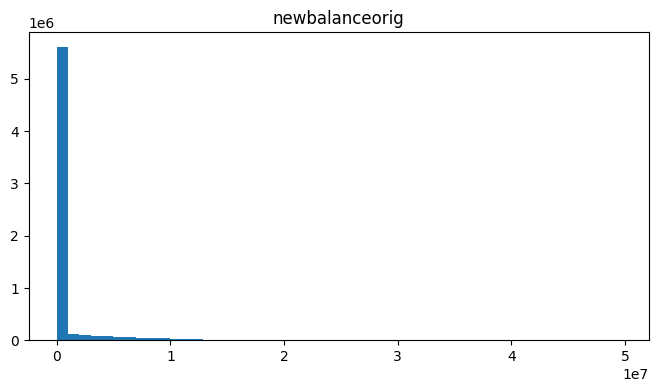

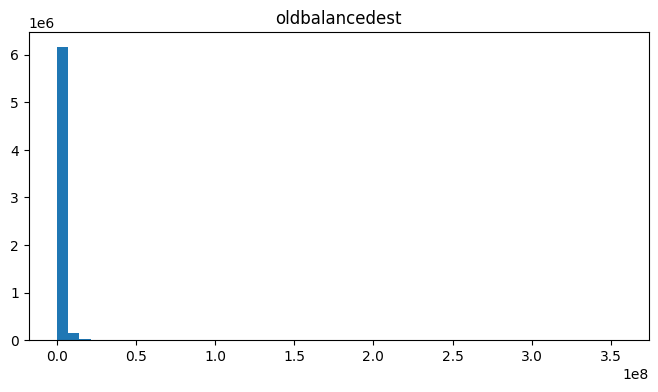

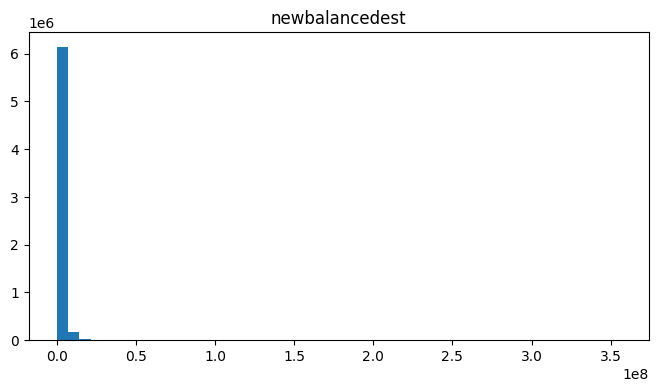

In [35]:
columns = [
    "oldbalanceorg",
    "newbalanceorig",
    "oldbalancedest",
    "newbalancedest"
]

for col in columns:

    plt.figure(figsize=(8,4))

    plt.hist(df[col], bins=50)

    plt.title(col)

    plt.show()

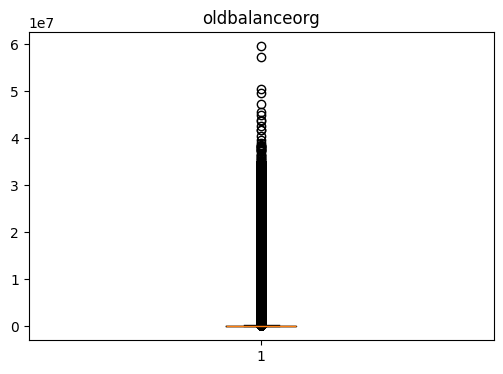

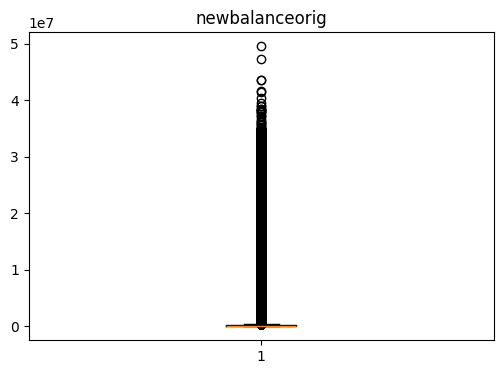

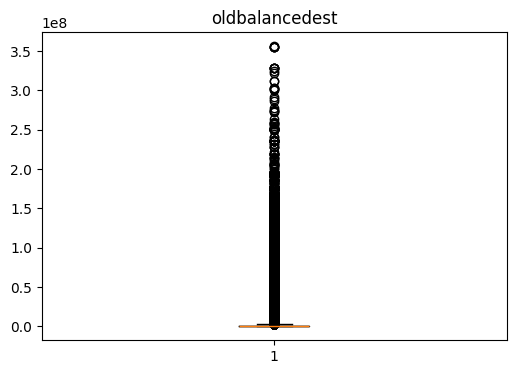

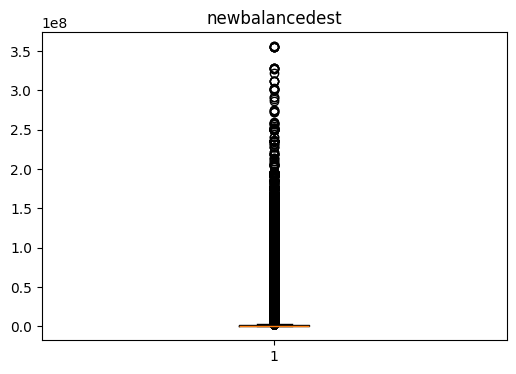

In [36]:
#boxplots

for col in columns:

    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

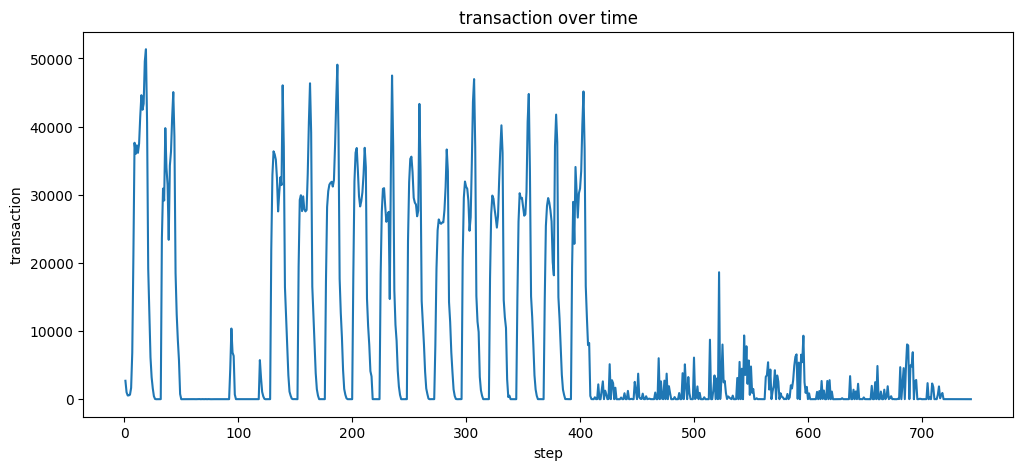

In [37]:
# time analysis 
# transaction over time 

step_count = df.groupby("step").size()
plt.figure(figsize=(12,5))
plt.plot(
    step_count.index,
    step_count.values
)
plt.title("transaction over time")
plt.xlabel("step")
plt.ylabel("transaction")
plt.show()

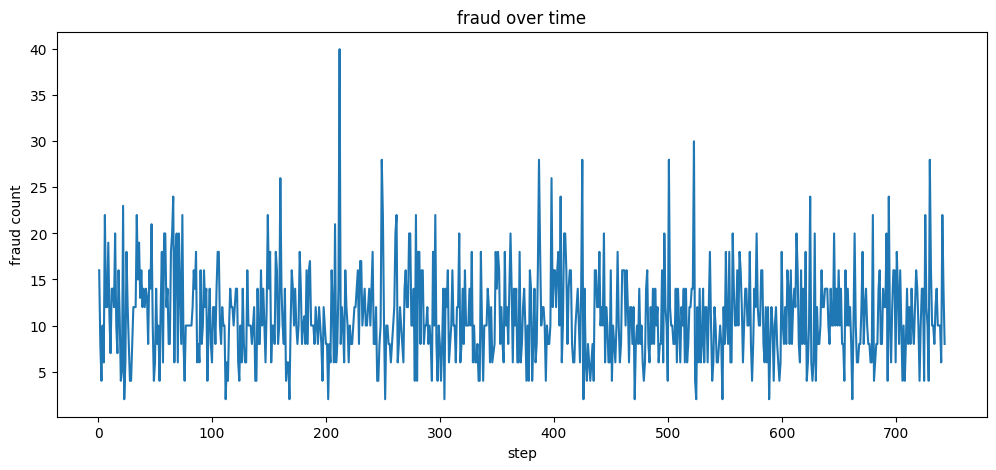

In [38]:
# fraud over time 
fraud_step = (
    df[df["isfraud"]==1].groupby("step").size()
)
plt.figure(figsize=(12,5))
plt.plot(
    fraud_step.index,
    fraud_step.values
)
plt.title("fraud over time")
plt.xlabel("step")
plt.ylabel("fraud count")
plt.show()

In [39]:
# correlation analysis 
corr = df.select_dtypes(include=["number"]).corr()
corr

,step,amount,oldbalanceorg,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceorg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceorig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalancedest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalancedest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isfraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isflaggedfraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


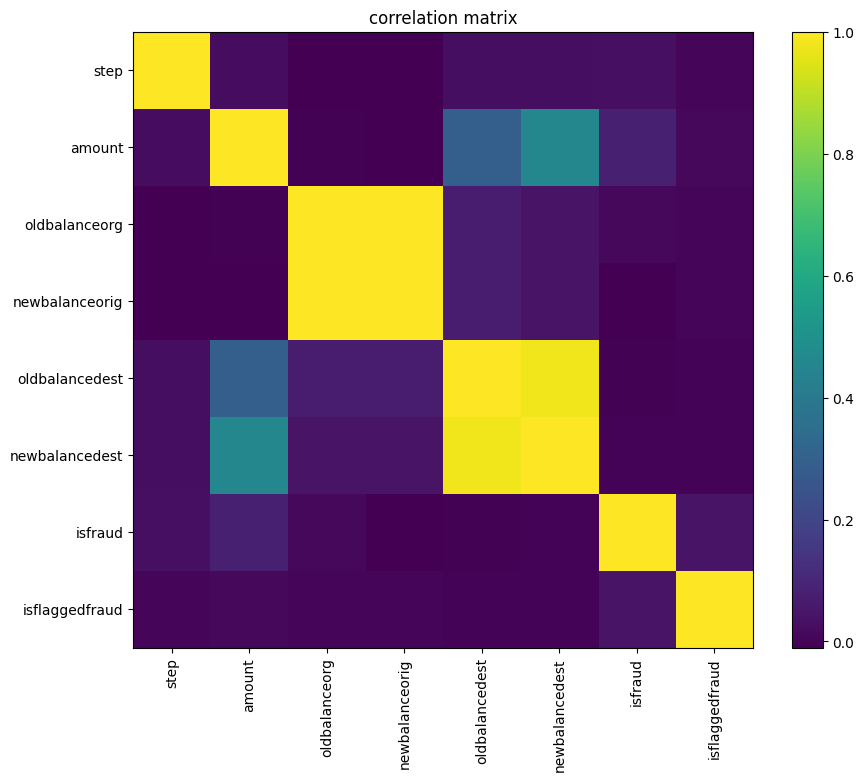

In [40]:
#heatmap

plt.figure(figsize=(10,8))
plt.imshow(corr,aspect="auto")
plt.colorbar()
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("correlation matrix")
plt.show()